# 📊 Trader Performance vs Market Sentiment Analysis

## Objective
The goal of this analysis is to understand how market sentiment (Fear/Greed) impacts trader behavior and performance.

We analyze:
- Profitability (PnL, Win Rate)
- Trading behavior (position size, long/short bias)
- Market sentiment influence

Additionally, a simple predictive model is built to estimate trade profitability.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("pandas, matplotlib, seaborn imported succesfully")

pandas, matplotlib, seaborn imported succesfully


## Data Loading

We load two datasets:
1. Market Sentiment Data (Fear/Greed index)
2. Historical Trader Data

These datasets will be combined later to analyze how sentiment affects trading behavior.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = '/content/drive/MyDrive'

In [ ]:
fear_greed = f'{folder_path}/fear_greed_index.csv'
sentiment = pd.read_csv(fear_greed)

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
history_data = f'{folder_path}/historical_data.csv'
trades = pd.read_csv(history_data)

trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print(trades.info())
print("Shape :",trades.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Data Inspection and Cleaning

### Initial Data Inspection
Using the `.info()` method, we examined the structure of the trades dataset, including data types and the presence of missing values.

### Missing Values Analysis
From this inspection, we observed that there are **no missing (null) values** in the dataset.

### Impact on Data Cleaning
Since the dataset is complete and does not contain null values, the data cleaning process was relatively straightforward. This allowed us to focus more on data transformation and analysis rather than handling missing data.

In [ ]:
print(sentiment.info())
print("shape", sentiment.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
shape (2644, 4)


## Data Inspection and Cleaning (Sentiment Dataset)

### Initial Data Inspection
Similar to the trades dataset, we used the `.info()` method to examine the structure and data types of the sentiment dataset.

### Missing Values Analysis
The sentiment dataset also contains **no missing (null) values**, consistent with the trades dataset.

### Impact on Data Cleaning
Since both datasets are complete and free of missing values, the data cleaning process was straightforward. This allowed us to focus directly on data transformation and merging.

In [ ]:
print("Columns are Trades :" ,trades.columns)
print("Columns are Sentiment :" ,sentiment.columns)

Columns are Trades : Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')
Columns are Sentiment : Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


## Data Cleaning & Preparation

- Converted timestamp columns to datetime format
- Extracted date from trade timestamps
- Ensured both datasets have a common `date` column

This allows us to merge datasets at a daily level.

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

sentiment['date'] = pd.to_datetime(sentiment['date'])
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


## Data Merging

The datasets are merged using the `date` column.

This enables us to associate each trade with the corresponding market sentiment (Fear, Greed, etc.).

In [ ]:
df = trades.merge(sentiment, on='date', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

/tmp/ipykernel_10675/2128389218.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, v, f"{percent[i]:.1f}%", ha='center')


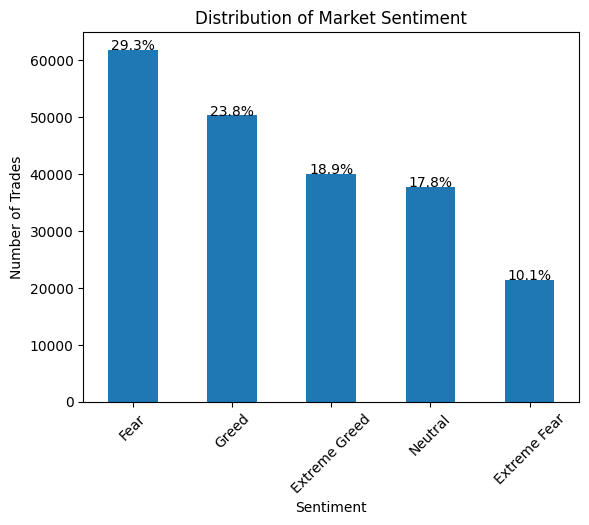

In [ ]:
counts = df['classification'].value_counts()
percent = df['classification'].value_counts(normalize=True) * 100

# Plot
plt.figure()
counts.plot(kind='bar')

# Add percentage labels on top
for i, v in enumerate(counts):
    plt.text(i, v, f"{percent[i]:.1f}%", ha='center')

plt.title("Distribution of Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

## Duplicate Data Check

### Method
To identify duplicate records, we used the `.duplicated()` function on the dataset.

### Observation
The analysis showed that there are **no duplicate records** present in the dataset.

### Impact
Since no duplicates were found, no additional data cleaning steps were required for handling duplicate entries. This ensures the integrity and reliability of the dataset for further analysis.

In [ ]:
duplicates = df[df.duplicated(keep=False)]
df.duplicated().sum()

np.int64(0)

## Feature Engineering

Created new features for analysis:

- `win`: Indicates whether a trade was profitable (Closed PnL > 0)

This helps evaluate trader performance across different sentiment conditions.

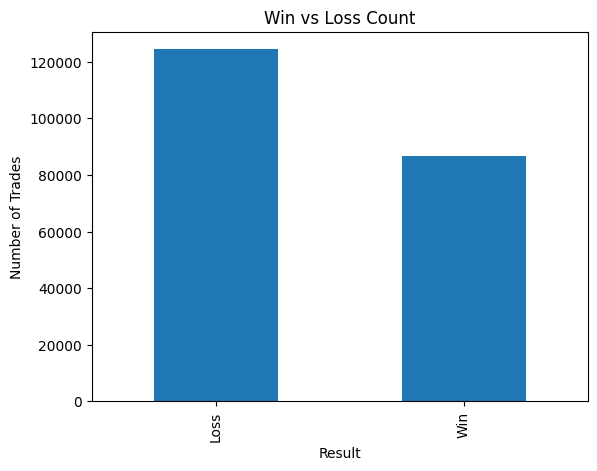

In [ ]:
df['win'] = df['Closed PnL'] > 0
df['win'].value_counts()
win_counts = df['win'].value_counts()

win_counts.index = ['Loss' if x == False else 'Win' for x in win_counts.index]

win_counts.plot(kind='bar')

plt.title('Win vs Loss Count')
plt.xlabel('Result')
plt.ylabel('Number of Trades')

plt.show()


## Win Rate Analysis

We calculate the win rate for each sentiment category.

This helps us understand how often traders are successful under different market conditions.

  classification   win
1  Extreme Greed 46.49
2           Fear 42.08
4        Neutral 39.70
3          Greed 38.48
0   Extreme Fear 37.06


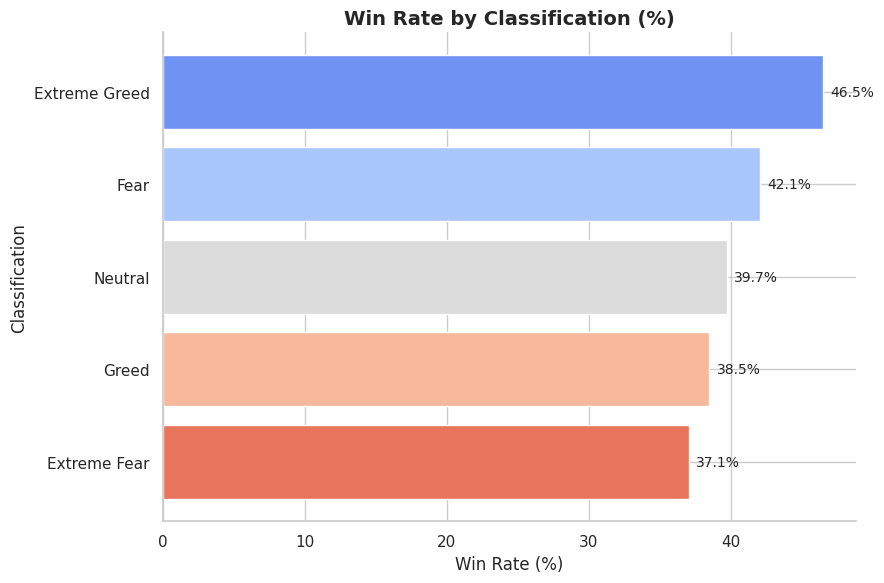

In [ ]:
win_rate = df.groupby('classification')['win'].mean().reset_index()
win_rate['win'] = win_rate['win'] * 100
win_rate = win_rate.sort_values(by='win', ascending=False)

print(win_rate)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9,6))

# color gradient based on value (very clean for analytics)
colors = sns.color_palette("coolwarm", len(win_rate))

bars = plt.barh(
    win_rate['classification'],
    win_rate['win'],
    color=colors
)

plt.title('Win Rate by Classification (%)', fontsize=14, weight='bold')
plt.xlabel('Win Rate (%)', fontsize=12)
plt.ylabel('Classification', fontsize=12)

plt.gca().invert_yaxis()

# value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()

## Trade Size Analysis

We analyze average trade size (Size USD) across sentiment groups.

This helps measure risk-taking behavior under different market conditions.

  classification  Size USD
2           Fear   7816.11
3          Greed   5736.88
0   Extreme Fear   5349.73
4        Neutral   4782.73
1  Extreme Greed   3112.25


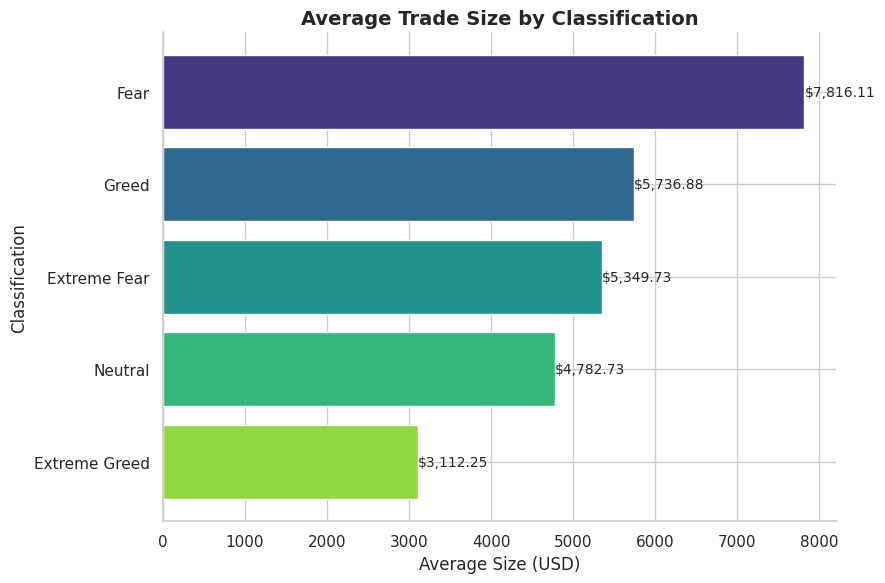

In [ ]:
size_analysis = df.groupby('classification')['Size USD'].mean().reset_index()
size_analysis = size_analysis.sort_values(by='Size USD', ascending=False)

print(size_analysis)

# style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9,6))

# color palette (professional look)
colors = sns.color_palette("viridis", len(size_analysis))

bars = plt.barh(
    size_analysis['classification'],
    size_analysis['Size USD'],
    color=colors
)

plt.title('Average Trade Size by Classification', fontsize=14, weight='bold')
plt.xlabel('Average Size (USD)', fontsize=12)
plt.ylabel('Classification', fontsize=12)

plt.gca().invert_yaxis()  # highest on top

# value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'${width:,.2f}',
        va='center',
        fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()

## Long vs Short Behavior

We examine the distribution of BUY vs SELL trades across sentiment categories.

This helps identify whether traders behave differently (e.g., more shorting during Greed).

Side             BUY  SELL
classification            
Extreme Fear   51.10 48.90
Extreme Greed  44.86 55.14
Fear           48.95 51.05
Greed          48.86 51.14
Neutral        50.33 49.67


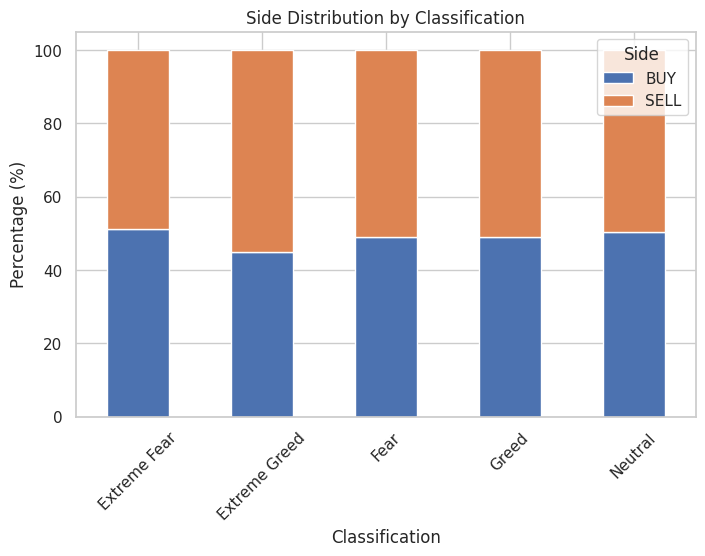

In [ ]:
counts = df.groupby(['classification', 'Side']).size()
side_percentage = counts.div(counts.groupby(level=0).sum(), level=0) * 100
side_percentage = side_percentage.unstack()

print(side_percentage)
side_percentage.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Side Distribution by Classification')
plt.xlabel('Classification')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=45)
plt.legend(title='Side')

plt.show()

## Profitability Analysis

We calculate total PnL across sentiment groups.

This helps determine which market conditions generate the highest profits.

  classification  Closed PnL
2           Fear  3357155.44
1  Extreme Greed  2715171.31
3          Greed  2150129.27
4        Neutral  1292920.68
0   Extreme Fear   739110.25


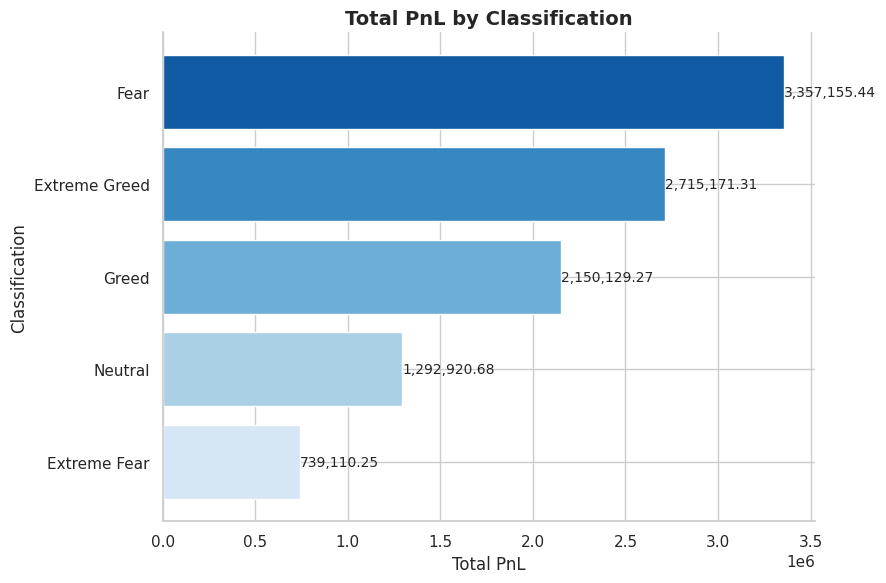

In [ ]:
total_pnl = df.groupby('classification')['Closed PnL'].sum().reset_index()
total_pnl = total_pnl.sort_values(by='Closed PnL', ascending=False)
pd.options.display.float_format = '{:.2f}'.format

print(total_pnl)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(9,6))

colors = sns.color_palette("Blues_r", len(total_pnl))

bars = plt.barh(
    total_pnl['classification'],
    total_pnl['Closed PnL'],
    color=colors
)

plt.title('Total PnL by Classification', fontsize=14, weight='bold')
plt.xlabel('Total PnL', fontsize=12)
plt.ylabel('Classification', fontsize=12)

plt.gca().invert_yaxis()

# value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.2f}',
        va='center',
        fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()

## Predictive Modeling

A Random Forest model is used to predict whether a trade will be profitable.

Features used:
- Trade size (Size USD)
- Trade direction (Side)
- Market sentiment (classification)

This model helps evaluate how predictable trading outcomes are.

In [ ]:
# Step 1: Select required columns
model_df = df[['Size USD', 'Side', 'classification', 'win']].copy()

# Step 2: Convert categorical variables to numeric
model_df = pd.get_dummies(model_df, columns=['Side', 'classification'], drop_first=True)

# Step 3: Define features (X) and target (y)
X = model_df.drop('win', axis=1)
y = model_df['win']

# Step 4: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Step 6: Predictions
y_pred = model.predict(X_test)

# Step 7: Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6595573440643863
              precision    recall  f1-score   support

       False       0.71      0.71      0.71     24802
        True       0.59      0.59      0.59     17443

    accuracy                           0.66     42245
   macro avg       0.65      0.65      0.65     42245
weighted avg       0.66      0.66      0.66     42245



## Model Evaluation

The model achieved ~66% accuracy.

This indicates that trader profitability is partially predictable using sentiment and behavior features.

In [ ]:
# Aggregate data per trader
trader_df = df.groupby('Account').agg({
    'Closed PnL': 'sum',        # total profit
    'win': 'mean',              # win rate
    'Size USD': 'mean',         # avg trade size
    'Trade ID': 'count'         # number of trades
}).reset_index()

# Rename columns
trader_df.columns = ['Account', 'total_pnl', 'win_rate', 'avg_size', 'trade_count']

print(trader_df.head())

                                      Account  total_pnl  win_rate  avg_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 1600229.82      0.36  16159.58   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   47885.32      0.44   1653.23   
2  0x271b280974205ca63b716753467d5a371de622ab  -70436.19      0.30   8893.00   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  132464.81      0.44    507.63   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  168658.00      0.52   3138.89   

   trade_count  
0         3818  
1         7280  
2         3809  
3        13311  
4         3239  


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
features = trader_df[['total_pnl', 'win_rate', 'avg_size', 'trade_count']]

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
trader_df['cluster'] = kmeans.fit_predict(scaled_features)

print(trader_df.head())

                                      Account  total_pnl  win_rate  avg_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 1600229.82      0.36  16159.58   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   47885.32      0.44   1653.23   
2  0x271b280974205ca63b716753467d5a371de622ab  -70436.19      0.30   8893.00   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  132464.81      0.44    507.63   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  168658.00      0.52   3138.89   

   trade_count  cluster  
0         3818        0  
1         7280        2  
2         3809        1  
3        13311        2  
4         3239        2  


In [ ]:
cluster_summary = trader_df.groupby('cluster')[['total_pnl', 'win_rate', 'avg_size', 'trade_count']].mean()

print(cluster_summary)

         total_pnl  win_rate  avg_size  trade_count
cluster                                            
0        955963.39      0.40  14150.21     14940.71
1        115092.80      0.32   4546.32      4820.15
2        175750.74      0.50   2841.68      3664.75


## Trader Behavioral Archetypes (Clustering Analysis)

### Cluster 0: High-Risk, High-Volume Traders
- Highest total profit
- Large trade sizes
- Very high trading frequency
- Moderate win rate (~40%)

**Interpretation:**
These traders follow a high-risk, high-reward strategy. Despite lower accuracy, they generate significant profits due to large position sizes and frequent trading.

---

### Cluster 1: Low-Performance Traders
- Lowest profit
- Lowest win rate (~32%)
- Average trade size and activity

**Interpretation:**
These traders struggle with both consistency and profitability. Their strategy may lack clear direction or risk management.

---

### Cluster 2: Consistent, Low-Risk Traders
- Highest win rate (~50%)
- Smaller trade sizes
- Lower trading frequency
- Moderate profits

**Interpretation:**
These traders focus on consistency and risk control. They achieve better accuracy but generate lower total profits due to smaller positions and fewer trades.

## Key Insights

### 1. Win Rate vs Sentiment
Traders achieve the highest win rate during **Extreme Greed** periods, indicating more favorable trading conditions or more controlled trading behavior in highly bullish markets.

---

### 2. Trade Size vs Performance
Despite taking **smaller position sizes**, traders in the **Extreme Greed** group achieve the highest win rates.

In contrast, traders in the **Fear** group take significantly larger position sizes and generate the **highest total profits**, suggesting a high-risk, high-reward trading approach.

---

### 3. Extreme Fear Performance
The **Extreme Fear** group shows the **lowest win rate and the lowest total profits** among all sentiment categories.

One possible reason is behavioral bias:
- Traders in this group tend to take more **long positions** and fewer short positions.
- From the analysis, it is observed that traders who take more **short positions** tend to achieve higher win rates.

This suggests that directional bias during extreme fear may negatively impact performance.

---

### 4. Sentiment Distribution and Profitability
The **Fear** sentiment category accounts for the largest share of trades (approximately 30%) and also generates the highest total profit.

On the other hand, the **Extreme Fear** group has the lowest representation in the dataset, which may contribute to its lower total profit.

This highlights the importance of both **trade frequency (volume)** and **trading behavior** in determining overall profitability.

### Key Takeaway

There is a clear trade-off between **win rate and profitability**:

- High-risk traders (Cluster 0) achieve higher profits despite lower win rates
- Consistent traders (Cluster 2) achieve higher win rates but lower profits

This highlights that **profitability is driven more by position sizing and trade frequency than win rate alone**.

## Strategy Recommendations

### 1. Risk-Control Strategy During Fear Periods
During **Fear** periods, traders tend to take significantly larger position sizes and generate high total profits, but with relatively lower win rates.

**Rule of Thumb:**
- Reduce position size to manage downside risk
- Avoid aggressive “all-in” trades despite potential high returns

**Rationale:**
Fear-driven markets encourage high-risk behavior. Controlling position size can help preserve capital while still capturing profitable opportunities.

---

### 2. Precision Trading Strategy During Extreme Greed
During **Extreme Greed** periods, traders achieve the highest win rates while using smaller position sizes and favoring short positions.

**Rule of Thumb:**
- Focus on smaller, more precise trades
- Consider short positions in overbought conditions

**Rationale:**
High win rates suggest more predictable market behavior, but smaller trade sizes indicate caution. A disciplined, low-risk approach can maximize consistency.

---

### 3. Avoid Directional Bias in Extreme Fear
Traders in **Extreme Fear** conditions tend to favor long positions and experience the lowest win rates and profitability.

**Rule of Thumb:**
- Avoid strong directional bias (especially excessive long positions)
- Incorporate short or hedging strategies when appropriate

**Rationale:**
Extreme Fear often leads to emotionally driven decisions. A balanced or contrarian approach may improve outcomes.